#**Capstone Project 2: Portuguese Bank Marketing Dataset**

**Definition:** (Portuguese Bank Marketing Dataset): A direct phone marketing campaign dataset from a Portuguese banking institution (May 2008 to November 2010). The objective is to predict whether a client will subscribe to a term deposit (target variable y).

#1. Project Objectives:

*  Primary Goal: Build a realistic machine learning predictive model to identify existing bank customers who are most likely to subscribe to a term deposit based on direct telephone marketing campaigns.

*  Task 1 (Data Analysis Report): Perform comprehensive Exploratory Data Analysis (EDA) on client demographics, economic conditions, and campaign features to extract actionable insights.
*  Task 2 (Predictive Modeling): Train, evaluate, and compare multiple machine learning algorithms (e.g., Logistic Regression, Random Forest, XGBoost) to accurately target potential subscribers.

*  Task 3 (Business & Marketing Strategy): Provide data-driven recommendations to the bank's marketing team to optimize future contact campaigns and increase subscription conversion rates.
*  Documentation Reports: Provide a formal Model Comparison Report and a Challenges Faced Report addressing issues like class imbalance, data encoding, and data leakage.


#2. Dataset Used Primary Source File:



*  Data > bank-additional > bank-additional-full.csv   Domain: Finance /Banking
*  Timeline: Direct telephone marketing campaigns conducted from May 2008 to November 2010.
* Dataset Size: 41,188 instances across 21 total attributes (20 input features + 1 target variable).
*  Delimitation: Semicolon separated (sep=';').



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve,f1_score
from sklearn.model_selection import train_test_split,cross_val_score

In [2]:
bank_1 = pd.read_csv('bank.csv')
bank_2 = pd.read_csv('bank-full.csv')
bank_3 = pd.read_csv('bank-additional.csv')
bank_4 = pd.read_csv('bank-additional_full.csv')
bank_final = pd.concat([bank_1,bank_2,bank_3,bank_4])
bank_final.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,pdays,previous,poutcome,y,day_of_week,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,30,unemployed,married,primary,no,1787.0,no,no,cellular,19.0,...,-1,0,unknown,no,NaN,NaN,NaN,NaN,NaN,NaN
1,33,services,married,secondary,no,4789.0,yes,yes,cellular,11.0,...,339,4,failure,no,NaN,NaN,NaN,NaN,NaN,NaN
2,35,management,single,tertiary,no,1350.0,yes,no,cellular,16.0,...,330,1,failure,no,NaN,NaN,NaN,NaN,NaN,NaN
3,30,management,married,tertiary,no,1476.0,yes,yes,unknown,3.0,...,-1,0,unknown,no,NaN,NaN,NaN,NaN,NaN,NaN
4,59,blue-collar,married,secondary,no,0.0,yes,no,unknown,5.0,...,-1,0,unknown,no,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
bank_final['y'] = bank_final['y'].map({'yes':1, 'no':0})

In [4]:
bank_final.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,pdays,previous,poutcome,y,day_of_week,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,30,unemployed,married,primary,no,1787.0,no,no,cellular,19.0,...,-1,0,unknown,0,NaN,NaN,NaN,NaN,NaN,NaN
1,33,services,married,secondary,no,4789.0,yes,yes,cellular,11.0,...,339,4,failure,0,NaN,NaN,NaN,NaN,NaN,NaN
2,35,management,single,tertiary,no,1350.0,yes,no,cellular,16.0,...,330,1,failure,0,NaN,NaN,NaN,NaN,NaN,NaN
3,30,management,married,tertiary,no,1476.0,yes,yes,unknown,3.0,...,-1,0,unknown,0,NaN,NaN,NaN,NaN,NaN,NaN
4,59,blue-collar,married,secondary,no,0.0,yes,no,unknown,5.0,...,-1,0,unknown,0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
bank_final.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,...,pdays,previous,poutcome,y,day_of_week,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
41183,73,retired,married,professional.course,no,NaN,yes,no,cellular,NaN,...,999,0,nonexistent,1,fri,-1.1,94.767,-50.8,1.028,4963.6
41184,46,blue-collar,married,professional.course,no,NaN,no,no,cellular,NaN,...,999,0,nonexistent,0,fri,-1.1,94.767,-50.8,1.028,4963.6
41185,56,retired,married,university.degree,no,NaN,yes,no,cellular,NaN,...,999,0,nonexistent,0,fri,-1.1,94.767,-50.8,1.028,4963.6
41186,44,technician,married,professional.course,no,NaN,no,no,cellular,NaN,...,999,0,nonexistent,1,fri,-1.1,94.767,-50.8,1.028,4963.6
41187,74,retired,married,professional.course,no,NaN,yes,no,cellular,NaN,...,999,1,failure,0,fri,-1.1,94.767,-50.8,1.028,4963.6


In [6]:
bank_final = bank_final.drop(bank_final.columns[17:23], axis=1)
bank_final.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787.0,no,no,cellular,19.0,oct,79,1,-1,0,unknown,0
1,33,services,married,secondary,no,4789.0,yes,yes,cellular,11.0,may,220,1,339,4,failure,0
2,35,management,single,tertiary,no,1350.0,yes,no,cellular,16.0,apr,185,1,330,1,failure,0
3,30,management,married,tertiary,no,1476.0,yes,yes,unknown,3.0,jun,199,4,-1,0,unknown,0
4,59,blue-collar,married,secondary,no,0.0,yes,no,unknown,5.0,may,226,1,-1,0,unknown,0


#EDA

In [7]:
bank_final.shape

(95039, 17)

In [8]:
bank_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95039 entries, 0 to 41187
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        95039 non-null  int64  
 1   job        95039 non-null  object 
 2   marital    95039 non-null  object 
 3   education  95039 non-null  object 
 4   default    95039 non-null  object 
 5   balance    49732 non-null  float64
 6   housing    95039 non-null  object 
 7   loan       95039 non-null  object 
 8   contact    95039 non-null  object 
 9   day        49732 non-null  float64
 10  month      95039 non-null  object 
 11  duration   95039 non-null  int64  
 12  campaign   95039 non-null  int64  
 13  pdays      95039 non-null  int64  
 14  previous   95039 non-null  int64  
 15  poutcome   95039 non-null  object 
 16  y          95039 non-null  int64  
dtypes: float64(2), int64(6), object(9)
memory usage: 13.1+ MB


In [9]:
bank_final.describe

<bound method NDFrame.describe of        age          job  marital            education default  balance  \
0       30   unemployed  married              primary      no   1787.0   
1       33     services  married            secondary      no   4789.0   
2       35   management   single             tertiary      no   1350.0   
3       30   management  married             tertiary      no   1476.0   
4       59  blue-collar  married            secondary      no      0.0   
...    ...          ...      ...                  ...     ...      ...   
41183   73      retired  married  professional.course      no      NaN   
41184   46  blue-collar  married  professional.course      no      NaN   
41185   56      retired  married    university.degree      no      NaN   
41186   44   technician  married  professional.course      no      NaN   
41187   74      retired  married  professional.course      no      NaN   

      housing loan   contact   day month  duration  campaign  pdays  previous  \
0          no   no  cellular  19.0   oct        79         1     -1         0   
1         yes  yes  cellular  11.0   may       220         1    339         4   
2         yes   no  cellular  16.0   apr       185         1    330         1   
3         yes  yes   unknown   3.0   jun       199         4     -1         0   
4         yes   no   unknown   5.0   may       226         1     -1         0   
...       ...  ...       ...   ...   ...       ...       ...    ...       ...   
41183     yes   no  cellular   NaN   nov       334         1    999         0   
41184      no   no  cellular   NaN   nov       383         1    999         0   
41185     yes   no  cellular   NaN   nov       189         2    999         0   
41186      no   no  cellular   NaN   nov       442         1    999         0   
41187     yes   no  cellular   NaN   nov       239         3    999         1   

          poutcome  y  
0          unknown  0  
1          failure  0  
2          failure  0  
3          unknown  0  
4          unknown  0  
...            ... ..  
41183  nonexistent  1  
41184  nonexistent  0  
41185  nonexistent  0  
41186  nonexistent  1  
41187      failure  0  

[95039 rows x 17 columns]>

In [10]:
bank_final.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,45307
housing,0
loan,0
contact,0
day,45307


In [11]:
bank_final['balance'].fillna(bank_final['balance'].median(), inplace=True)

/tmp/ipykernel_358/179906062.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bank_final['balance'].fillna(bank_final['balance'].median(), inplace=True)


In [12]:
bank_final['day'].fillna(bank_final['day'].mode()[0], inplace=True)

/tmp/ipykernel_358/4033569809.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bank_final['day'].fillna(bank_final['day'].mode()[0], inplace=True)


In [13]:
bank_final.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


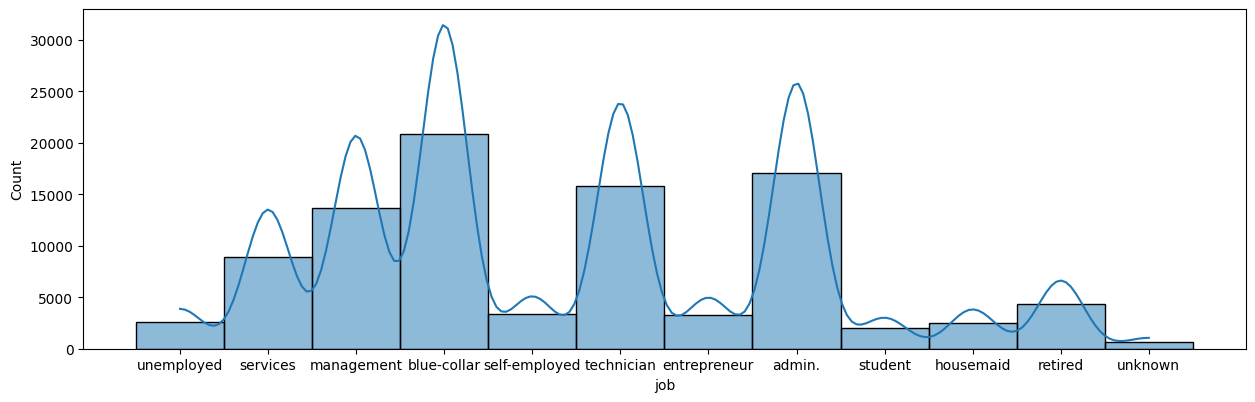

In [14]:
figure=plt.figure(figsize=(15,15))
for i in range(1,2):
    plt.subplot(3,1,i)
    sns.histplot(bank_final.iloc[:,i],kde=True)

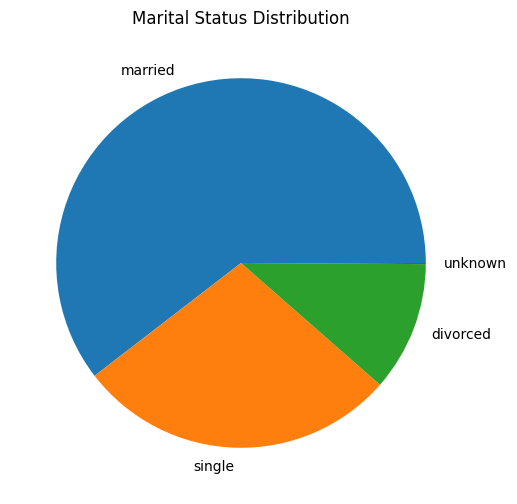

In [15]:
# Count the values in the marital column
marital_counts = bank_final['marital'].value_counts()

# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(
    marital_counts,
    labels=marital_counts.index,
)
plt.title("Marital Status Distribution")
plt.show()

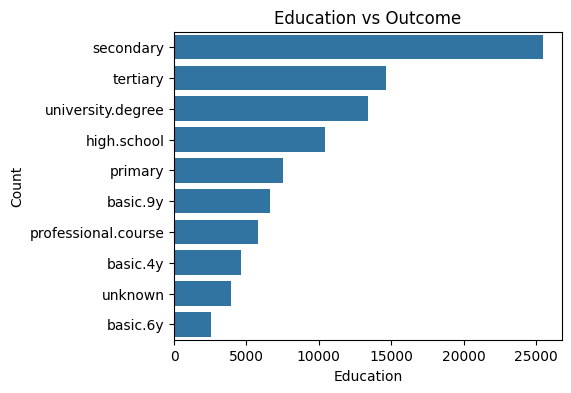

In [16]:
Education = bank_final['education'].value_counts().head(10)

plt.figure(figsize=(5,4))
sns.barplot(y=Education.index, x=Education.values )
plt.title("Education vs Outcome")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

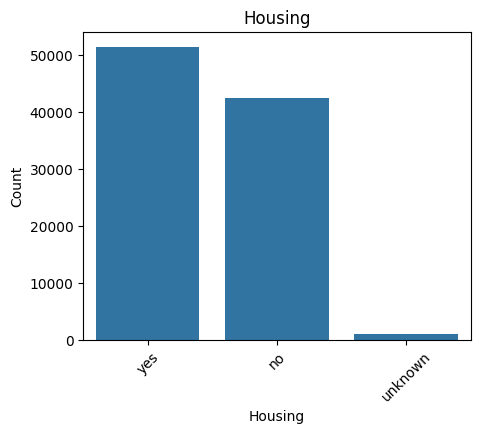

In [17]:
Housing = bank_final['housing'].value_counts().head(10)

plt.figure(figsize=(5,4))
sns.barplot(x=Housing.index, y=Housing.values)
plt.title("Housing")
plt.xlabel("Housing")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

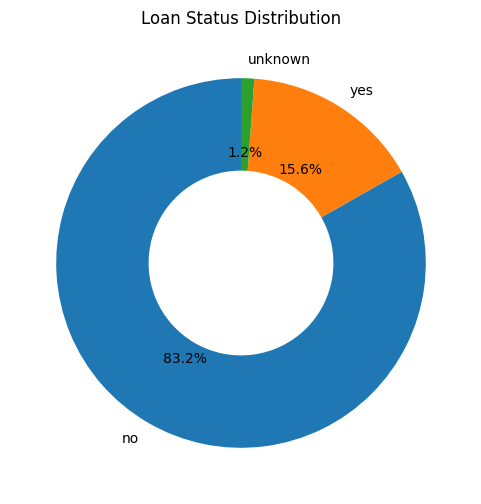

In [18]:
# Count values in loan column
Loan = bank_final['loan'].value_counts()

# Donut chart
plt.figure(figsize=(6,6))
plt.pie(
    Loan,
    labels=Loan.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.5}
)
plt.title("Loan Status Distribution")
plt.show()

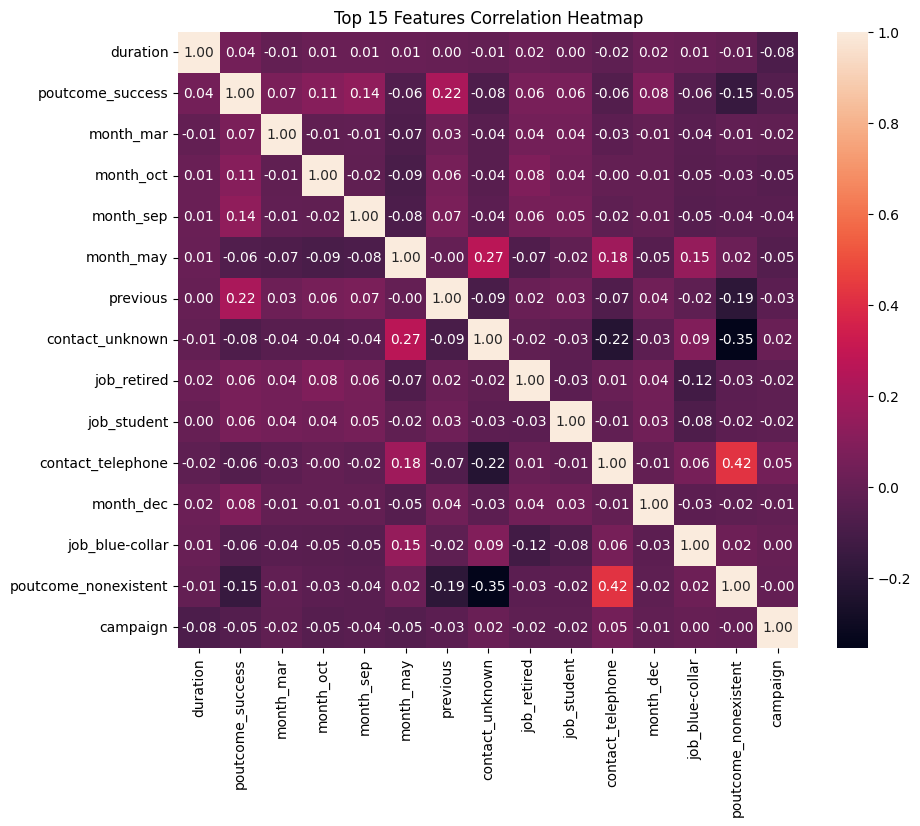

In [19]:
# Step 1: Encode categorical variables
bank_encoded = pd.get_dummies(
    bank_final,
    columns=['job','marital','education','default','housing','loan','contact','month','poutcome'],
    drop_first=True
)

# Step 2: Compute correlation matrix
corr = bank_encoded.corr()

# Step 3: Select top N features (excluding 'y')
top_features = corr.drop('y')['y'].abs().sort_values(ascending=False).head(15).index

# Step 4: Plot heatmap of only those features
plt.figure(figsize=(10,8))
sns.heatmap(bank_encoded[top_features].corr(), annot=True, fmt=".2f")
plt.title("Top 15 Features Correlation Heatmap")
plt.show()

#Logistic Regression

In [20]:
bank_final.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787.0,no,no,cellular,19.0,oct,79,1,-1,0,unknown,0
1,33,services,married,secondary,no,4789.0,yes,yes,cellular,11.0,may,220,1,339,4,failure,0
2,35,management,single,tertiary,no,1350.0,yes,no,cellular,16.0,apr,185,1,330,1,failure,0
3,30,management,married,tertiary,no,1476.0,yes,yes,unknown,3.0,jun,199,4,-1,0,unknown,0
4,59,blue-collar,married,secondary,no,0.0,yes,no,unknown,5.0,may,226,1,-1,0,unknown,0


In [21]:
y = bank_final.y
x = bank_final.loc[:,['age','balance','day','duration','campaign','pdays','previous']]

In [22]:
log_reg = LogisticRegression()

In [23]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=10)

In [24]:
x_train.shape

(66527, 7)

In [25]:
x_test.shape

(28512, 7)

In [26]:
log_reg.fit(x_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [27]:
y_predict = log_reg.predict(x_test)
y_predict

array([0, 0, 0, ..., 0, 0, 0])

In [28]:
y_test

,y
27683,0
32738,0
30494,0
39056,0
24943,0
...,...
2451,0
16557,0
21592,0
23051,0


In [29]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     25268
           1       0.56      0.16      0.25      3244

    accuracy                           0.89     28512
   macro avg       0.73      0.57      0.60     28512
weighted avg       0.86      0.89      0.86     28512



In [30]:
confusion_matrix(y_test,y_predict)

array([[24853,   415],
       [ 2721,   523]])

In [31]:
acc_train = accuracy_score(y_test,y_predict)
acc_train

0.8900112233445566

In [32]:
y_prob = log_reg.predict_proba(x_test)[:,1]
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1]:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    print(f"Threshold: {thresh}")
    print(classification_report(y_test, y_pred_thresh))
    print(accuracy_score(y_test, y_pred_thresh))
    print(confusion_matrix(y_test, y_pred_thresh))
    print("-"*50)

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.92      0.95      0.93     25268
           1       0.47      0.33      0.39      3244

    accuracy                           0.88     28512
   macro avg       0.69      0.64      0.66     28512
weighted avg       0.87      0.88      0.87     28512

0.8806116722783389
[[24026  1242]
 [ 2162  1082]]
--------------------------------------------------
Threshold: 0.4
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     25268
           1       0.52      0.23      0.32      3244

    accuracy                           0.89     28512
   macro avg       0.71      0.60      0.63     28512
weighted avg       0.86      0.89      0.87     28512

0.8881874298540965
[[24576   692]
 [ 2496   748]]
--------------------------------------------------
Threshold: 0.5
              precision    recall  f1-score   support

           0       0.90      0.98      0.94 

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [34]:
y_prob = log_reg.predict_proba(X_test_scaled)[:,1]
y_prob

array([0.1425895 , 0.27841657, 0.27686093, ..., 0.3005819 , 0.13449952,
       0.34213656])

In [35]:
thresholds = np.arange(0.1, 1.0, 0.05)
f1_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    f1_scores.append((thresh, f1))

best_thresh, best_f1 = max(f1_scores, key=lambda x: x[1])
print(f"Best threshold: {best_thresh:.2f} with F1 score: {best_f1:.3f}")

Best threshold: 0.60 with F1 score: 0.470


In [36]:
y_pred_best = (y_prob >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_best))
print(accuracy_score(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91     25268
           1       0.39      0.60      0.47      3244

    accuracy                           0.85     28512
   macro avg       0.67      0.74      0.69     28512
weighted avg       0.88      0.85      0.86     28512

0.8471871492704826
[[22224  3044]
 [ 1313  1931]]


#Suggessions:

The bank’s marketing team should focus on smarter campaigns by targeting customer groups with higher chances of subscribing, such as retired individuals, educated professionals, and stable job categories like management or technicians, while prioritizing mobile calls over landlines, choosing favorable economic periods for outreach, and limiting repeated contacts to avoid customer fatigue; additionally, retargeting customers who had successful outcomes in past campaigns and using predictive models to personalize offers will help increase conversions, reduce wasted effort, lower campaign costs, and build stronger long‑term customer trust.

#Conclusions

The analysis of the Portuguese Bank dataset demonstrates that customer subscription to term deposits is strongly influenced by demographic profiles, contact strategies, and economic conditions; predictive modeling confirms that focusing on educated professionals, retired individuals, and stable job categories, while prioritizing cellular outreach and limiting repeated contacts, can significantly improve campaign success, and therefore the bank should adopt a data‑driven marketing approach to increase efficiency, reduce costs, and strengthen customer relationships.